In [1]:
%load_ext autoreload
%autoreload 2

import mc_sim as mc
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

In [3]:
#film = [6.0, 0.58, 0.5, 0.9]
#film = [13.0, 0.58, 0.5, 0.9]
film = [77.0, 0.56, 0.5, 0.9]
#film = [3930.0, 0.5, 1, 0.9]

wvls = np.linspace(0.400, 0.800, 100)  # 400nm - 800nm
theta = np.linspace(0.01, np.pi-0.01, 500)      # 0 ~ 180도
r_i = 0.138
n_m = 1.0               # 공기 매질 굴절률
k_p = 2e-5              # imaginary refractive index of PS


film_thickness = film[0]
phi = film[1]              # 6, 13um
fine_roughness = film[2]
coarse_roughness = film[3]

In [5]:
def structure_factor_heatmap_with_cdf(wvl_array, r_i,
                                           k_p,
                                           theta_array, n_med,
                                           phi, is_normal, is_temp):
    
    cdf_2D = np.zeros((len(wvl_array), len(theta_array)))
    median_thetas = np.zeros(len(wvls))
    l_scats = np.zeros(len(wvls))
    
    for i, wvl in enumerate(wvl_array):
        n_p_real = mc.get_np_real(wvl)
        
        if is_temp: 
            Phase_norm, Phase_surf = mc.get_phase_func_ginoza(wavelength=wvl, theta=theta_array, 
                                                          r_mean=r_i, pdi=0.03, phi=phi, 
                                                          k_p=2e-5, n_p_real=n_p_real, n_m=n_med)
        else:
            Phase_norm, Phase_surf = mc.get_phase_func_ginoza_old(wavelength=wvl, theta=theta_array, 
                                                          r_mean=r_i, pdi=0.03, phi=phi, 
                                                          k_p=2e-5, n_p_real=n_p_real, n_m=n_med)
        if is_normal: 
            cdf = mc.cdf_phase(Phase_norm, theta_array)
            l_scat = mc.get_l_scat(Phase_norm, theta_array, phi, r_i)
        else: 
            cdf = mc.cdf_phase(Phase_surf, theta_array)
            l_scat = mc.get_l_scat(Phase_surf, theta_array, phi, r_i)
        
        
        cdf_2D[i, :] = cdf
        median_theta = np.interp(0.5, cdf, theta_array)
        median_thetas[i] = median_theta
        l_scats[i] = l_scat
    
    return cdf_2D, median_thetas, l_scats
    
cdf_2D_norm, median_thetas_norm, l_scat_norm = structure_factor_heatmap_with_cdf(
                                       wvl_array=wvls, r_i=r_i,
                                       k_p=k_p,
                                       theta_array=theta, n_med=n_m,
                                       phi=phi, is_normal=True, is_temp=False)
cdf_2D_surf, median_thetas_surf, l_scat_surf = structure_factor_heatmap_with_cdf(
                                       wvl_array=wvls, r_i=r_i,
                                       k_p=k_p,
                                       theta_array=theta, n_med=n_m,
                                       phi=phi, is_normal=False, is_temp=False)

cdf_2D_normt, median_thetas_normt, l_scat_normt = structure_factor_heatmap_with_cdf(
                                       wvl_array=wvls, r_i=r_i,
                                       k_p=k_p,
                                       theta_array=theta, n_med=n_m,
                                       phi=phi, is_normal=True, is_temp=True)
cdf_2D_surft, median_thetas_surft, l_scat_surft = structure_factor_heatmap_with_cdf(
                                       wvl_array=wvls, r_i=r_i,
                                       k_p=k_p,
                                       theta_array=theta, n_med=n_m,
                                       phi=phi, is_normal=False, is_temp=True)

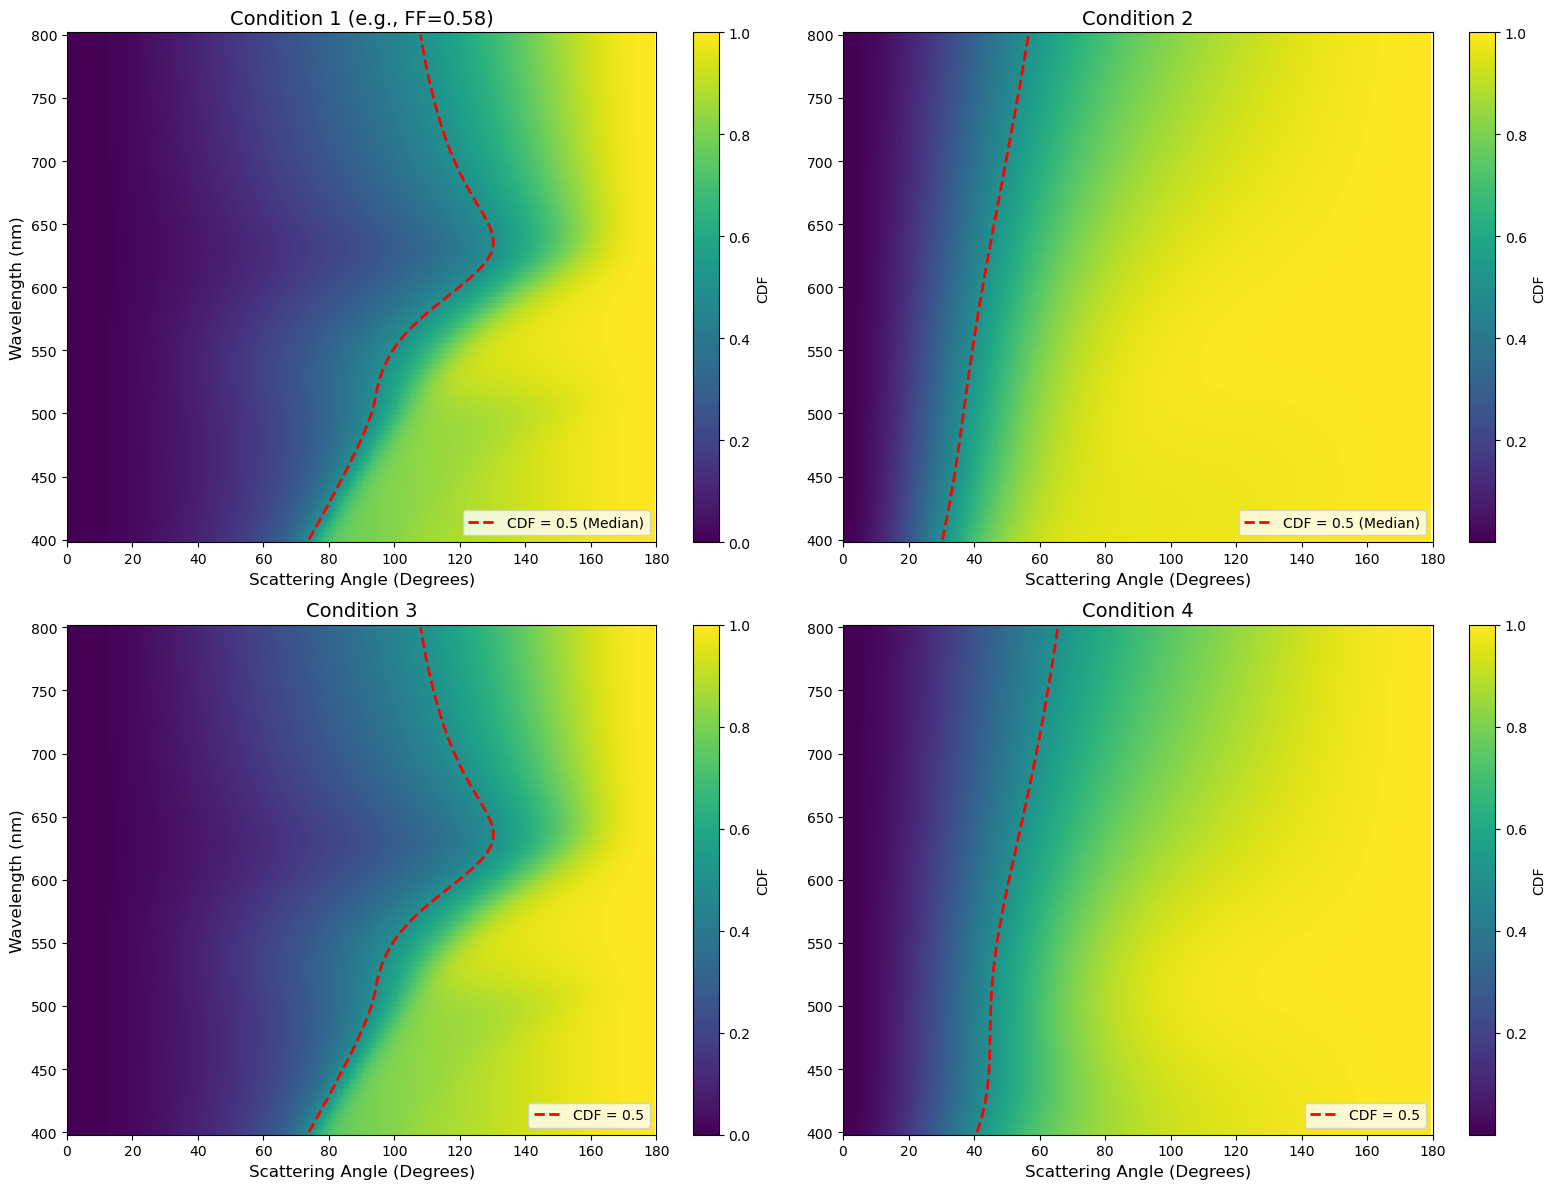

In [29]:
fig, axs = plt.subplots(2, 2, figsize=(16, 12))

# 코드를 보기 편하게 축 변수를 직관적으로 할당해 둡니다.
ax1 = axs[0, 0] # 1행 1열 (왼쪽 위)
ax2 = axs[0, 1] # 1행 2열 (오른쪽 위)
ax3 = axs[1, 0] # 2행 1열 (왼쪽 아래)
ax4 = axs[1, 1] # 2행 2열 (오른쪽 아래)

# ==========================================
# --- 첫 번째 그래프 (왼쪽, ax1) ---
# ==========================================
# (데이터 변수명은 실제 사용하시는 변수로 바꿔주세요: cdf_2D_1, median_thetas_1 등)
mesh1 = ax1.pcolormesh(np.degrees(theta), wvls * 1000, cdf_2D_norm, 
                       cmap='viridis', shading='auto')

ax1.plot(np.degrees(median_thetas_norm), wvls * 1000, 
         color='red', linestyle='--', linewidth=2, label='CDF = 0.5 (Median)')

# 축 설정 및 꾸미기 (plt. ➔ ax1.set_ 형태로 변경됨)
fig.colorbar(mesh1, ax=ax1, label='CDF') # ax1에 종속된 컬러바 생성
ax1.set_xlabel('Scattering Angle (Degrees)', fontsize=12)
ax1.set_ylabel('Wavelength (nm)', fontsize=12)
ax1.set_title('Condition 1 (e.g., FF=0.58)', fontsize=14)
ax1.set_xlim(0, 180)
ax1.legend(loc='lower right')

# ==========================================
# --- 두 번째 그래프 (오른쪽, ax2) ---
# ==========================================
mesh2 = ax2.pcolormesh(np.degrees(theta), wvls * 1000, cdf_2D_surf, 
                       cmap='viridis', shading='auto')

ax2.plot(np.degrees(median_thetas_surf), wvls * 1000, 
         color='red', linestyle='--', linewidth=2, label='CDF = 0.5 (Median)')

# 축 설정 및 꾸미기
fig.colorbar(mesh2, ax=ax2, label='CDF') # ax2에 종속된 컬러바 생성
ax2.set_xlabel('Scattering Angle (Degrees)', fontsize=12)
# ax2.set_ylabel('Wavelength (nm)', fontsize=12) # Y축 라벨은 왼쪽 그래프에만 있어도 충분할 때가 많습니다.
ax2.set_title('Condition 2', fontsize=14)
ax2.set_xlim(0, 180)
ax2.legend(loc='lower right')

# ==========================================
# --- 3. 왼쪽 아래 (ax3) ---
# ==========================================
mesh3 = ax3.pcolormesh(np.degrees(theta), wvls * 1000, cdf_2D_normt, cmap='viridis', shading='auto')
ax3.plot(np.degrees(median_thetas_normt), wvls * 1000, 'r--', lw=2, label='CDF = 0.5')
fig.colorbar(mesh3, ax=ax3, label='CDF')

ax3.set_xlabel('Scattering Angle (Degrees)', fontsize=12)
ax3.set_ylabel('Wavelength (nm)', fontsize=12)
ax3.set_title('Condition 3', fontsize=14)
ax3.set_xlim(0, 180)
ax3.legend(loc='lower right')

# ==========================================
# --- 4. 오른쪽 아래 (ax4) ---
# ==========================================
mesh4 = ax4.pcolormesh(np.degrees(theta), wvls * 1000, cdf_2D_surft, cmap='viridis', shading='auto')
ax4.plot(np.degrees(median_thetas_surft), wvls * 1000, 'r--', lw=2, label='CDF = 0.5')
fig.colorbar(mesh4, ax=ax4, label='CDF')

ax4.set_xlabel('Scattering Angle (Degrees)', fontsize=12)
ax4.set_title('Condition 4', fontsize=14)
ax4.set_xlim(0, 180)
ax4.legend(loc='lower right')
# ==========================================
# 마무리
# ==========================================
plt.tight_layout() # 그래프 간격 자동 최적화
plt.show()

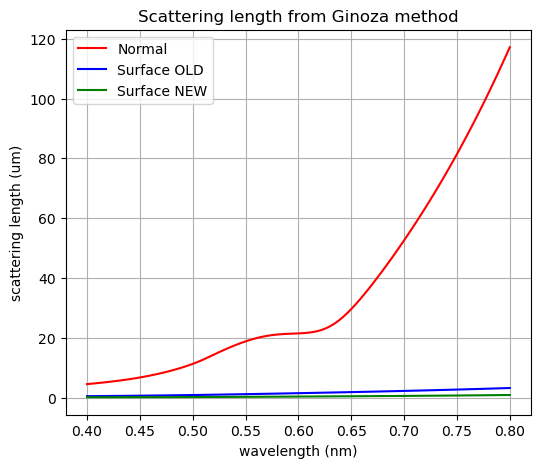

In [21]:
l_scat_norm = l_scat_norm
l_scat_surf_old = l_scat_surf
l_scat_surf_new = l_scat_surft

plt.figure(figsize=(6, 5))
# --- 첫 번째 그래프 (왼쪽, ax1) ---
plt.plot(wvls, l_scat_norm, 'r-', label="Normal")
plt.plot(wvls, l_scat_surf, 'b-', label="Surface OLD")
plt.plot(wvls, l_scat_surft, 'g-', label="Surface NEW")

plt.title("Scattering length from Ginoza method")
plt.xlabel("wavelength (nm)")
plt.ylabel("scattering length (um)")
plt.legend()
plt.grid(True)

# 화면에 출력
plt.show()